# Rental Pricing Dataset, Malaysia

Dataset Link: https://www.kaggle.com/datasets/ariewijaya/rent-pricing-kuala-lumpur-malaysi

In [1]:
!pip install pandas matplotlib numpy seaborn scikit-learn catboost xgboost

Defaulting to user installation because normal site-packages is not writeable
ERROR: Error while checking for conflicts. Please file an issue on pip's issue tracker: https://github.com/pypa/pip/issues/new
Traceback (most recent call last):
  File "/usr/lib/python3.13/site-packages/pip/_internal/commands/install.py", line 584, in _determine_conflicts
    return check_install_conflicts(to_install)
  File "/usr/lib/python3.13/site-packages/pip/_internal/operations/check.py", line 117, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
                     ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/site-packages/pip/_internal/operations/check.py", line 59, in create_package_set_from_installed
    package_set[name] = PackageDetails(dist.version, dependencies)
                                       ^^^^^^^^^^^^
  File "/usr/lib/python3.13/site-packages/pip/_internal/metadata/importlib/_dists.py", line 168, in version
    return parse_vers

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
# Turn on or off code that takes long to run
train_MLP = True;
hyperparameter_tuning_RandomForest = True;
hyperparameter_tuning_XGBoost = True;
hyperparameter_tuning_CatBoost = True;

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [5]:
df = pd.read_csv("mudah-apartment-kl-selangor.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19991 entries, 0 to 19990
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ads_id                 19991 non-null  int64  
 1   prop_name              19043 non-null  object 
 2   completion_year        10806 non-null  float64
 3   monthly_rent           19989 non-null  object 
 4   location               19991 non-null  object 
 5   property_type          19991 non-null  object 
 6   rooms                  19985 non-null  object 
 7   parking                14289 non-null  float64
 8   bathroom               19985 non-null  float64
 9   size                   19991 non-null  object 
 10  furnished              19986 non-null  object 
 11  facilities             17782 non-null  object 
 12  additional_facilities  14043 non-null  object 
 13  region                 19991 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 2.1+

In [6]:
df.head(2)

,ads_id,prop_name,completion_year,monthly_rent,location,property_type,rooms,parking,bathroom,size,furnished,facilities,additional_facilities,region
0,100323185,The Hipster @ Taman Desa,2022.0,RM 4 200 per month,Kuala Lumpur - Taman Desa,Condominium,5,2.0,6.0,1842 sq.ft.,Fully Furnished,"Minimart, Gymnasium, Security, Playground, Swimming Pool, Parking, Lift, Barbeque area, Multipurpose hall, Jogging Track","Air-Cond, Cooking Allowed, Washing Machine",Kuala Lumpur
1,100203973,Segar Courts,NaN,RM 2 300 per month,Kuala Lumpur - Cheras,Condominium,3,1.0,2.0,1170 sq.ft.,Partially Furnished,"Playground, Parking, Barbeque area, Security, Jogging Track, Swimming Pool, Gymnasium, Lift, Sauna","Air-Cond, Cooking Allowed, Near KTM/LRT",Kuala Lumpur


## Data Cleaning

In [7]:
df = df.drop(["ads_id"], axis=1)

In [8]:
# Strip text from the rental price
df['monthly_rent'] = (
    df['monthly_rent']
    .str.replace('RM', '', regex=False)
    .str.replace('per month', '', regex=False)
    .str.replace(' ', '', regex=False)
)

df['monthly_rent'] = pd.to_numeric(df['monthly_rent'], errors='coerce')

In [9]:
# Fill missing parking counts with 1 if facilities mention parking
mask = (
    df['parking'].isna() &
    df['facilities'].str.lower().str.contains('parking', na=False)
)

df.loc[mask, 'parking'] = 1
print(f'Total rows filled with 1 for parking field {mask.sum()}')
print(f'Parking with NULL Values {df['parking'].isna().sum()}')

Total rows filled with 1 for parking field 3754
Parking with NULL Values 1948


In [10]:
# Drop the 'Kuala Lumput -' from the location field
df['location'] = df['location'].str.replace(r'^(Kuala Lumpur|Selangor)\s*-\s*', '', regex=True)
print(df['location'].nunique())

129


In [11]:
# Drop the sq.ft. from size
df["size"] = df["size"].str.extract(r"(\d+)").astype(int)

In [12]:
# Encode furnished into one-hot encodings
df["fully_furnished"] = (
    df["furnished"]
    .str.strip()
    .str.lower()
    .eq("fully furnished")
    .astype(int)
)
df = df.drop(columns=["furnished"])

In [13]:
# Convert year information into age
# 2023 is used as the dataset was scrapped in that year
current_year = 2023
df["property_age"] = current_year - df["completion_year"]
df = df.drop(columns=["completion_year"])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19991 entries, 0 to 19990
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   prop_name              19043 non-null  object 
 1   monthly_rent           19989 non-null  float64
 2   location               19991 non-null  object 
 3   property_type          19991 non-null  object 
 4   rooms                  19985 non-null  object 
 5   parking                18043 non-null  float64
 6   bathroom               19985 non-null  float64
 7   size                   19991 non-null  int64  
 8   facilities             17782 non-null  object 
 9   additional_facilities  14043 non-null  object 
 10  region                 19991 non-null  object 
 11  fully_furnished        19991 non-null  int64  
 12  property_age           10806 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [15]:
# Convert facilities data into one hot encodings
facilities_one_hot = df["facilities"].str.get_dummies(sep=", ")

# FIX: Removed axis=1 since columns=[...] is explicitly defined
facilities_one_hot = facilities_one_hot.drop(columns=["10", "11", "6"])

additional_facilities_one_hot = df["additional_facilities"].str.get_dummies(sep=", ")

df = df.join(facilities_one_hot)
df = df.join(additional_facilities_one_hot)

# FIX: Removed axis=1 since columns=[...] is explicitly defined
df = df.drop(columns=["facilities", "additional_facilities"])

In [16]:
# Remove anomalies of rental greater than RM18500 per month
num_removed = (df['monthly_rent'] > 18500).sum()
print(f"Rows to remove: {num_removed}")
df = df[df['monthly_rent'] <= 18500]

# Remove anomalies of rental less than RM300 per month
num_removed = (df['monthly_rent'] < 300).sum()
print(f"Rows to remove: {num_removed}")
df = df[df['monthly_rent'] >= 300]

Rows to remove: 35
Rows to remove: 51


In [17]:
df[['parking', 'rooms', 'bathroom']] = df[['parking', 'rooms' , 'bathroom']].fillna(0)

In [18]:
df['age_missing'] = df['property_age'].isna().astype(int)

df['property_age'] = df['property_age'].fillna(
    df['property_age'].median()
)

In [19]:
# Group Rare Categories of houses
# print(df['location'].unique())
# print(df['property_type'].unique())
# df['property_type'].value_counts()

rare_types = [
    'Others',
    'Duplex',
    'Townhouse Condo',
    'Houses'
]

df['property_type'] = df['property_type'].replace(
    rare_types,
    'Other'
)

In [20]:
null_row_count = df.isna().any(axis=1).sum()

print(f"Rows with nulls: {null_row_count}")

Rows with nulls: 936


In [21]:
# Convert rooms to numerical numbers and removing abnormal data with strong
df = df[df['rooms'] != 'More than 10']
df['rooms'] = pd.to_numeric(df['rooms'])

In [22]:
df.isna().sum().sort_values(ascending=False)

prop_name            935
monthly_rent           0
location               0
property_type          0
rooms                  0
parking                0
bathroom               0
size                   0
region                 0
fully_furnished        0
property_age           0
Barbeque area          0
Club house             0
Gymnasium              0
Jogging Track          0
Lift                   0
Minimart               0
Multipurpose hall      0
Parking                0
Playground             0
Sauna                  0
Security               0
Squash Court           0
Swimming Pool          0
Tennis Court           0
Air-Cond               0
Cooking Allowed        0
Internet               0
Near KTM/LRT           0
Washing Machine        0
age_missing            0
dtype: int64

## Exploratory Data Analysis

/tmp/ipykernel_23041/4044126601.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,2].set_xticklabels(


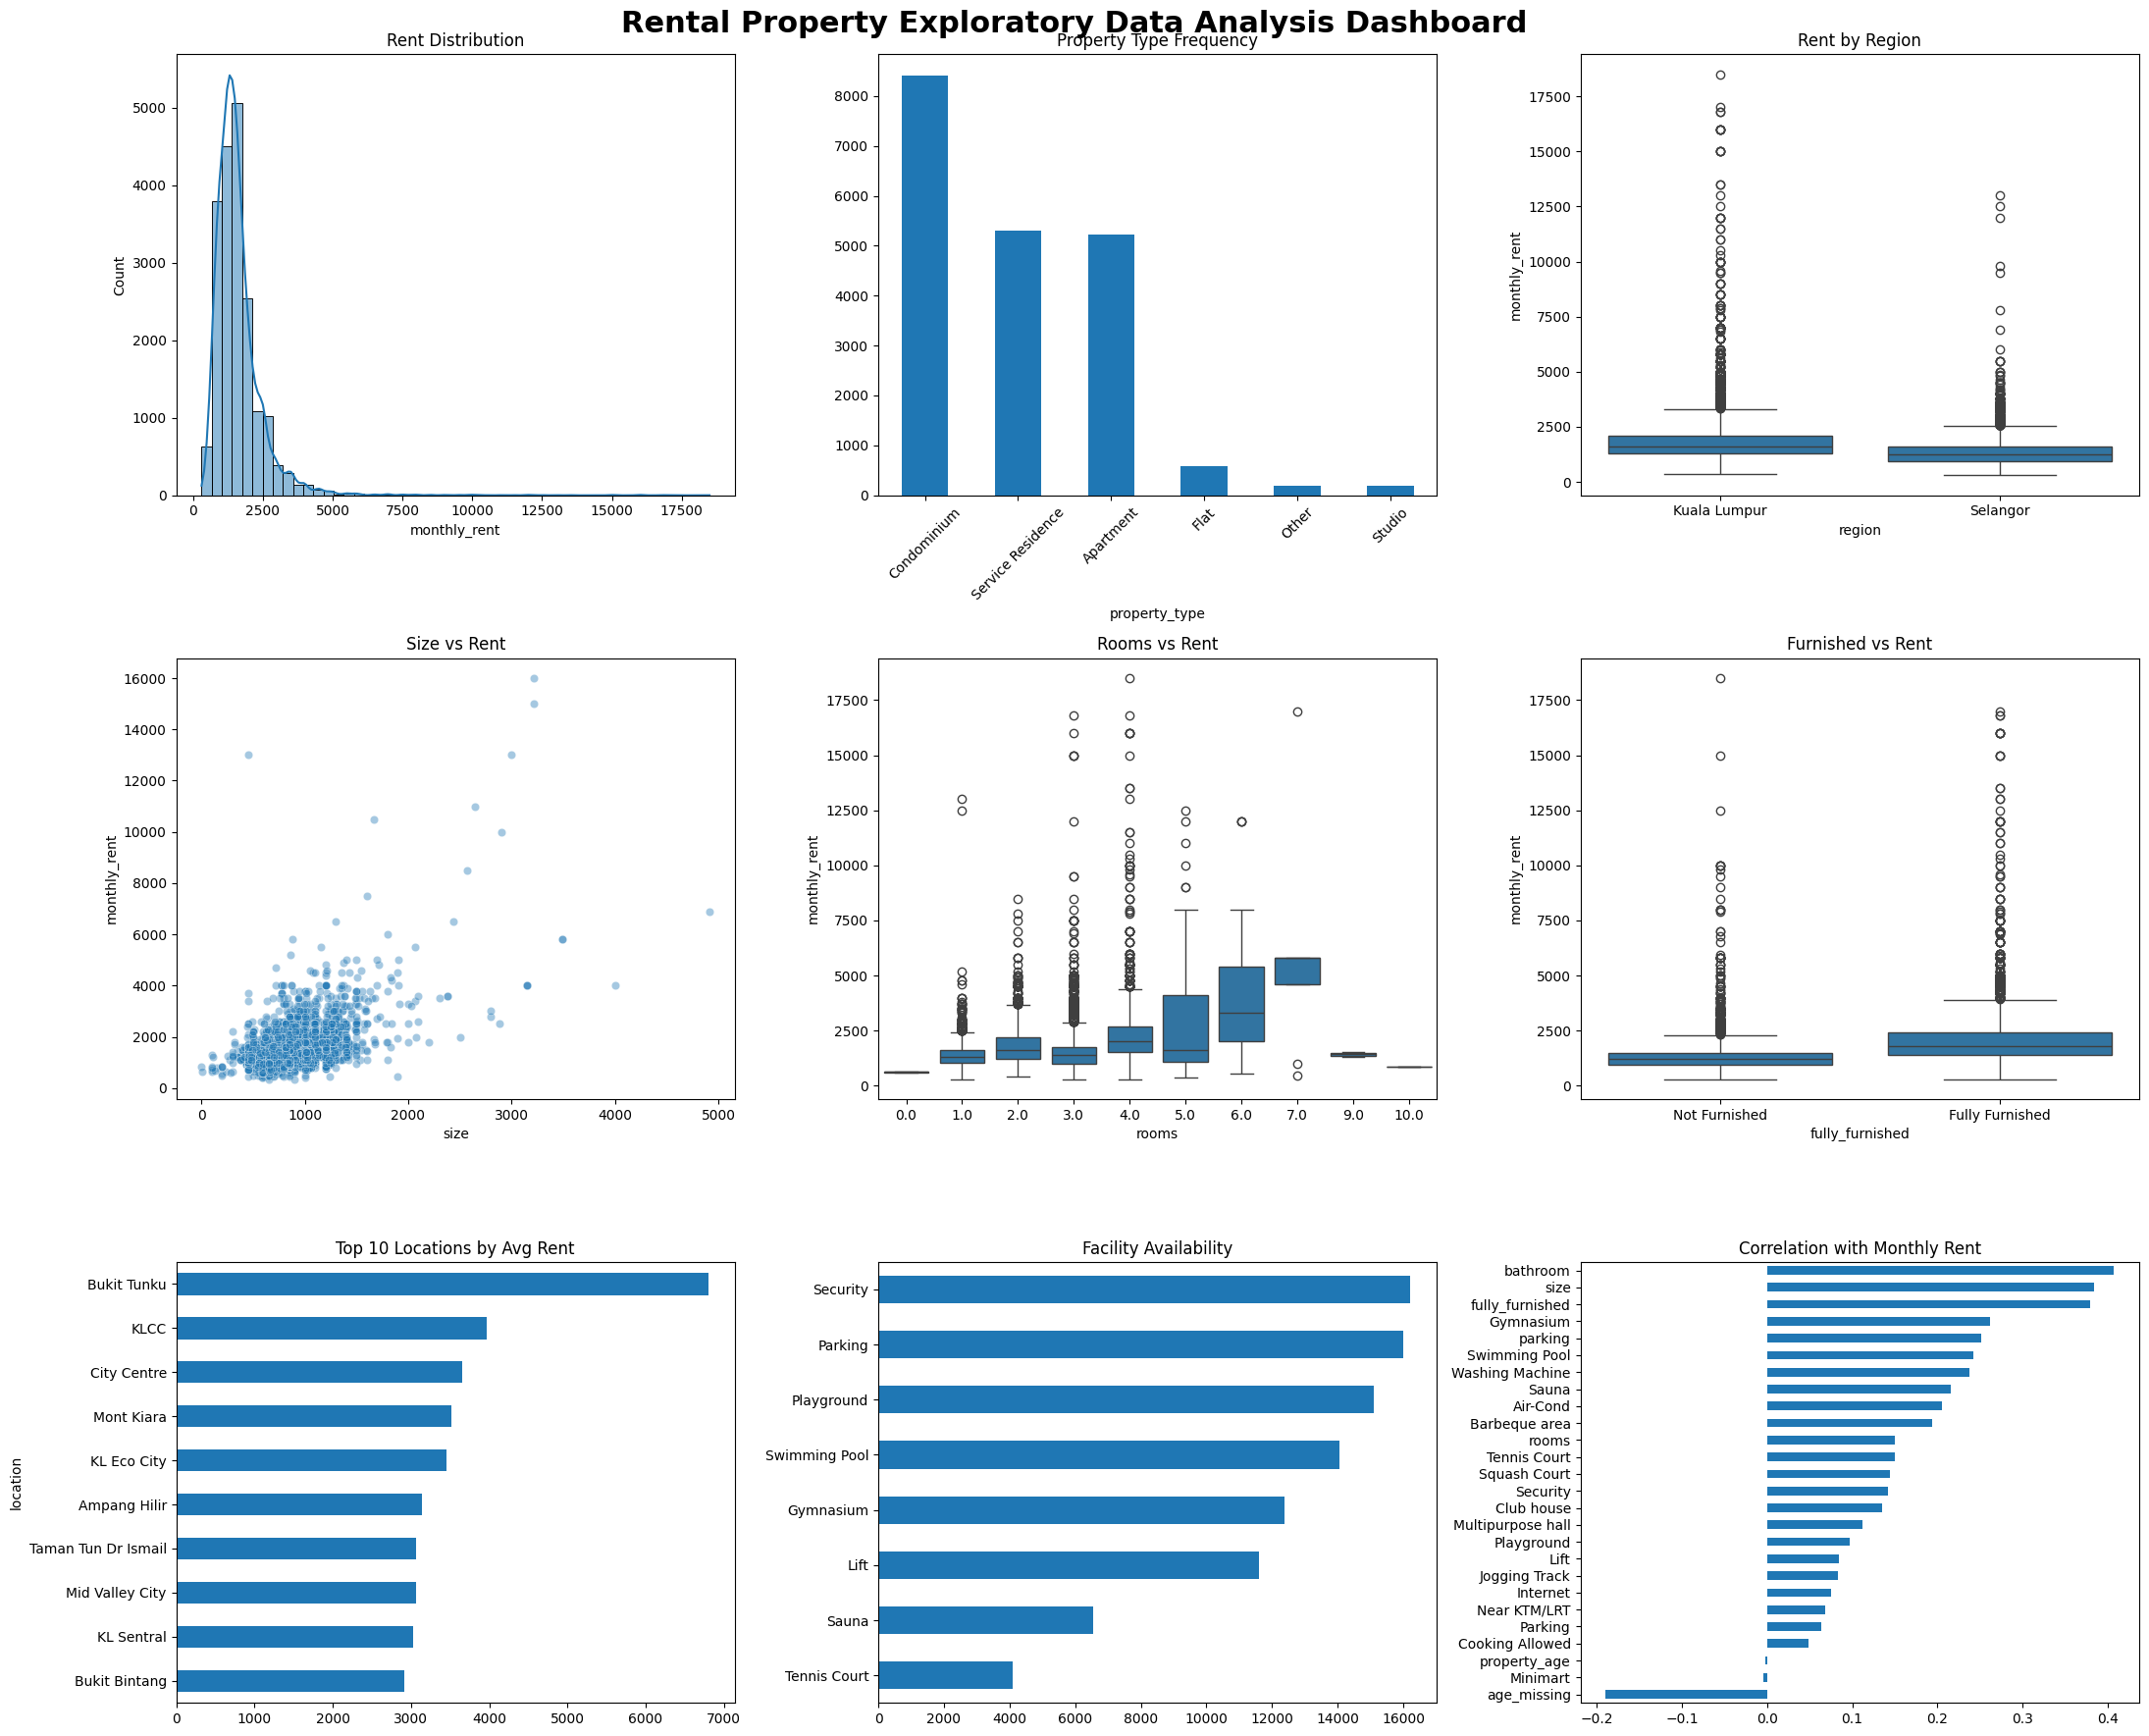

In [23]:
# Region column
# df['region'] = np.where(
#     df['region_Kuala Lumpur']==1,
#     'Kuala Lumpur',
#     'Selangor'
# )

fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle('Rental Property Exploratory Data Analysis Dashboard',
             fontsize=22,
             fontweight='bold')

# -------------------------------------------------
# 1. Rent Distribution
# -------------------------------------------------
sns.histplot(df['monthly_rent'],
             bins=50,
             kde=True,
             ax=axes[0,0])

axes[0,0].set_title('Rent Distribution')

# -------------------------------------------------
# 2. Property Type Count
# -------------------------------------------------
df['property_type'].value_counts().plot(
    kind='bar',
    ax=axes[0,1]
)

axes[0,1].set_title('Property Type Frequency')
axes[0,1].tick_params(axis='x', rotation=45)

# -------------------------------------------------
# 3. Region Comparison
# -------------------------------------------------
sns.boxplot(
    data=df,
    x='region',
    y='monthly_rent',
    ax=axes[0,2]
)

axes[0,2].set_title('Rent by Region')

# -------------------------------------------------
# 4. Size vs Rent
# -------------------------------------------------
sns.scatterplot(
    data=df.sample(min(3000, len(df))),
    x='size',
    y='monthly_rent',
    alpha=0.4,
    ax=axes[1,0]
)

axes[1,0].set_title('Size vs Rent')

# -------------------------------------------------
# 5. Rooms vs Rent
# -------------------------------------------------
sns.boxplot(
    data=df,
    x='rooms',
    y='monthly_rent',
    ax=axes[1,1]
)

axes[1,1].set_title('Rooms vs Rent')

# -------------------------------------------------
# 6. Furnished vs Rent
# -------------------------------------------------
sns.boxplot(
    data=df,
    x='fully_furnished',
    y='monthly_rent',
    ax=axes[1,2]
)

axes[1,2].set_title('Furnished vs Rent')
axes[1,2].set_xticklabels(
    ['Not Furnished','Fully Furnished']
)

# -------------------------------------------------
# 7. Top Locations
# -------------------------------------------------
top_loc = (
    df.groupby('location')['monthly_rent']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_loc.sort_values().plot(
    kind='barh',
    ax=axes[2,0]
)

axes[2,0].set_title('Top 10 Locations by Avg Rent')

# -------------------------------------------------
# 8. Common Facilities
# -------------------------------------------------
facilities = [
    'Swimming Pool',
    'Gymnasium',
    'Security',
    'Parking',
    'Playground',
    'Lift',
    'Sauna',
    'Tennis Court'
]

df[facilities].sum().sort_values().plot(
    kind='barh',
    ax=axes[2,1]
)

axes[2,1].set_title('Facility Availability')

# -------------------------------------------------
# 9. Correlation with Rent
# -------------------------------------------------
corr = (
    df.select_dtypes(include=['int64','float64'])
      .corr()['monthly_rent']
      .sort_values()
)

corr.drop('monthly_rent').plot(
    kind='barh',
    ax=axes[2,2]
)

axes[2,2].set_title('Correlation with Monthly Rent')

plt.tight_layout()
plt.show()

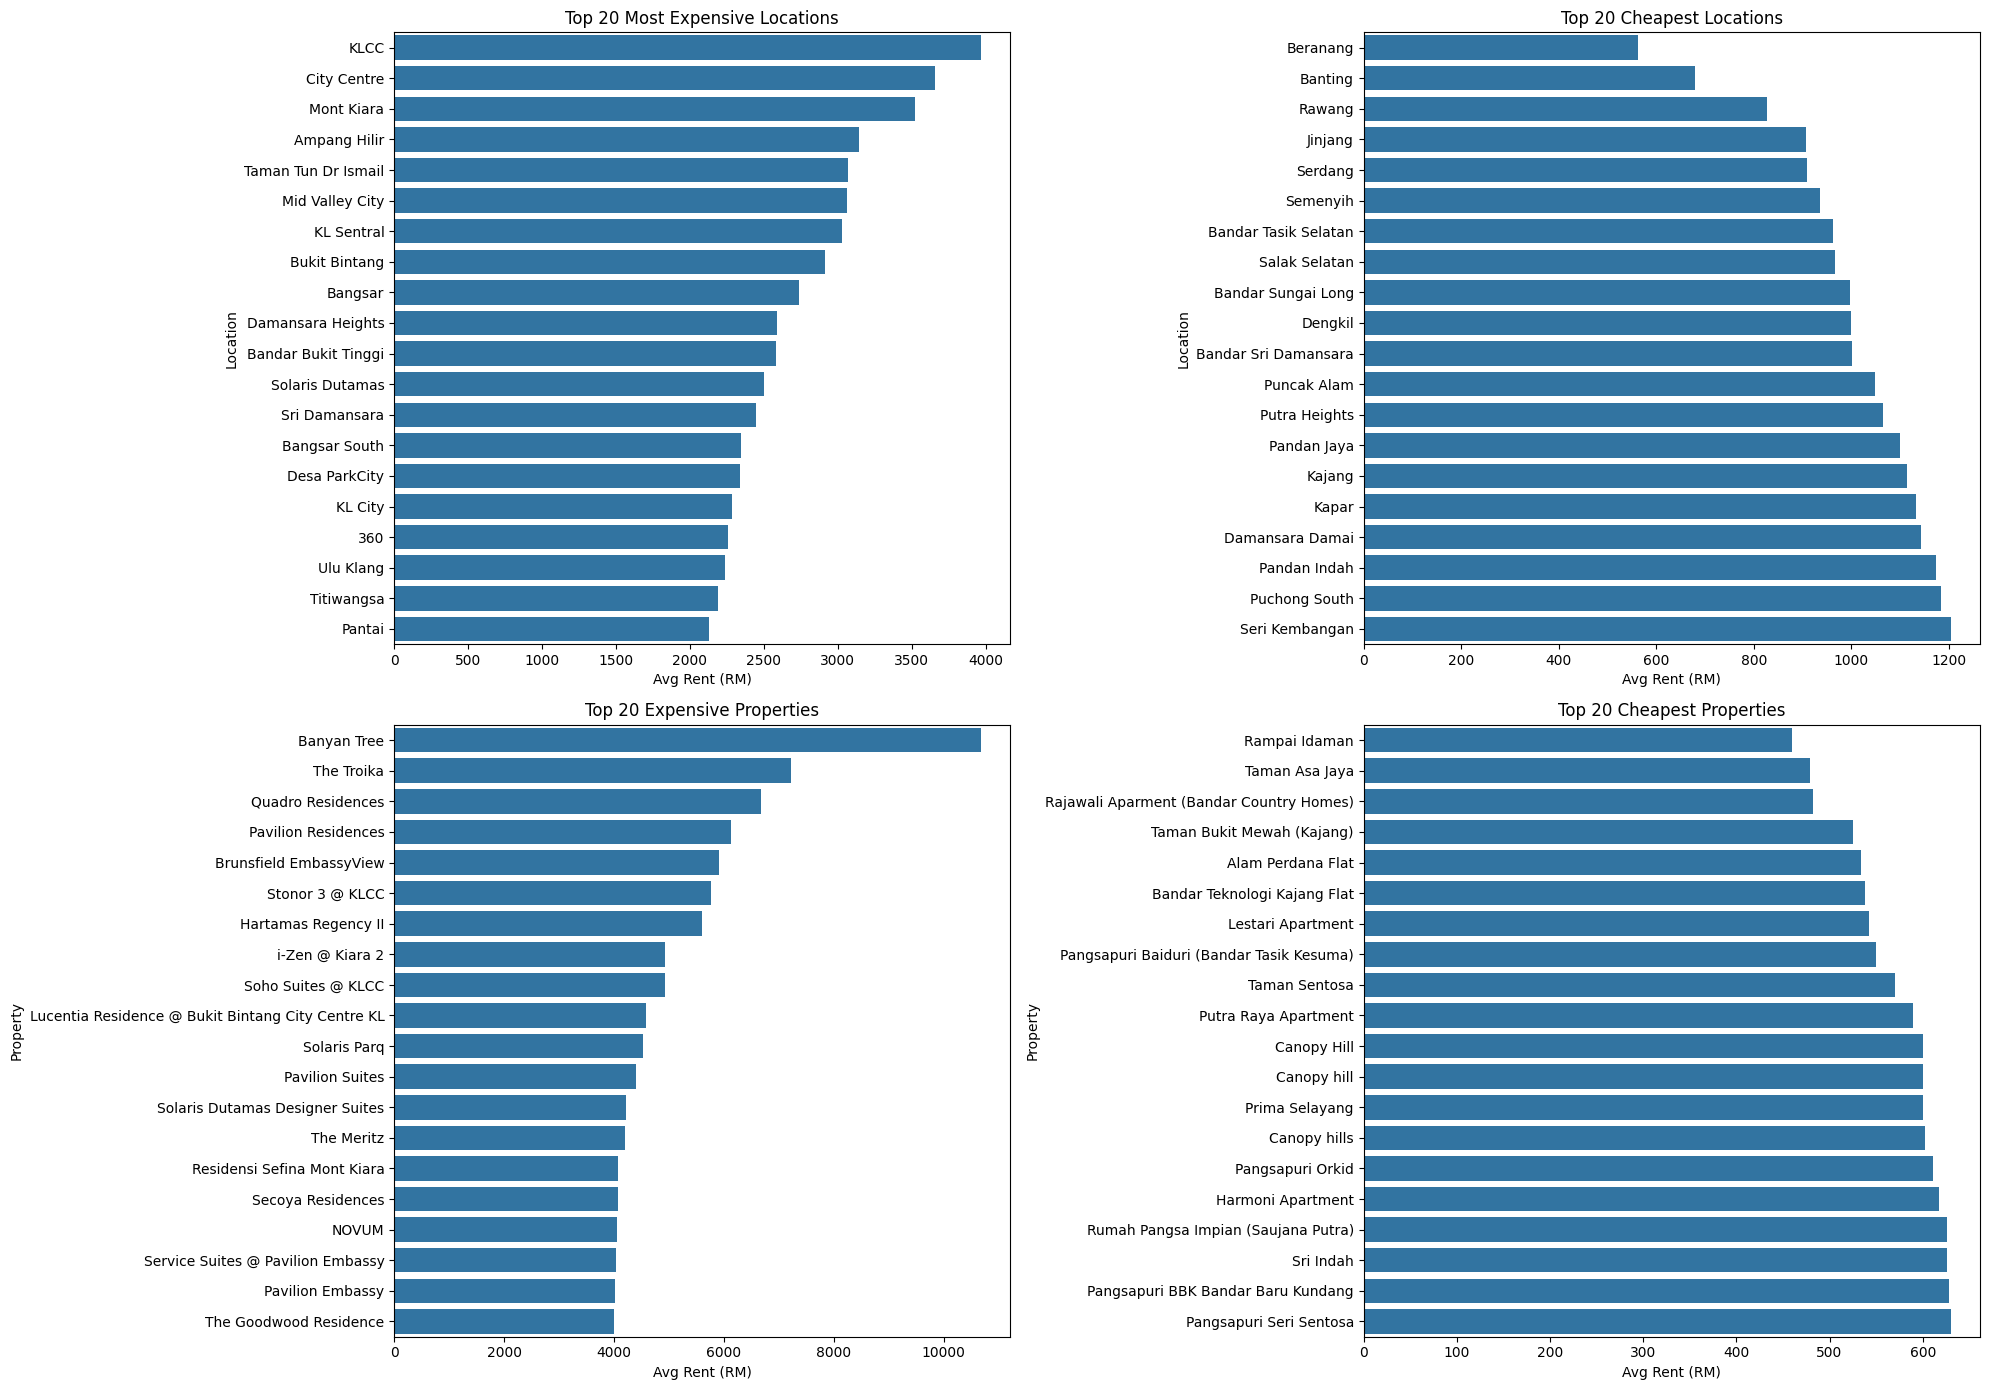

In [24]:
location_stats = (
    df.groupby('location')['monthly_rent']
      .agg(['count', 'mean'])
      .query('count >= 5')
)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# -------------------------
# 1. Top expensive locations
# -------------------------
top_loc = location_stats.sort_values('mean', ascending=False).head(20)

sns.barplot(
    data=top_loc.reset_index(),
    x='mean',
    y='location',
    ax=axes[0,0]
)
axes[0,0].set_title('Top 20 Most Expensive Locations')
axes[0,0].set_xlabel('Avg Rent (RM)')
axes[0,0].set_ylabel('Location')

# -------------------------
# 2. Cheapest locations
# -------------------------
bottom_loc = location_stats.sort_values('mean', ascending=True).head(20)

sns.barplot(
    data=bottom_loc.reset_index(),
    x='mean',
    y='location',
    ax=axes[0,1]
)
axes[0,1].set_title('Top 20 Cheapest Locations')
axes[0,1].set_xlabel('Avg Rent (RM)')
axes[0,1].set_ylabel('Location')

# -------------------------
# 3. Expensive properties
# -------------------------
top_prop = (
    df.groupby('prop_name')['monthly_rent']
      .agg(['count', 'mean'])
      .query('count >= 5')
      .sort_values('mean', ascending=False)
      .head(20)
)

sns.barplot(
    data=top_prop.reset_index(),
    x='mean',
    y='prop_name',
    ax=axes[1,0]
)
axes[1,0].set_title('Top 20 Expensive Properties')
axes[1,0].set_xlabel('Avg Rent (RM)')
axes[1,0].set_ylabel('Property')

# -------------------------
# 4. Cheapest properties
# -------------------------
bottom_prop = (
    df.groupby('prop_name')['monthly_rent']
      .agg(['count', 'mean'])
      .query('count >= 5')
      .sort_values('mean', ascending=True)
      .head(20)
)

sns.barplot(
    data=bottom_prop.reset_index(),
    x='mean',
    y='prop_name',
    ax=axes[1,1]
)
axes[1,1].set_title('Top 20 Cheapest Properties')
axes[1,1].set_xlabel('Avg Rent (RM)')
axes[1,1].set_ylabel('Property')

plt.tight_layout()
plt.show()

## Feature Selection and Data Encoding

In [25]:
# Remove property name from the dataframe
df_property_name = df.pop('prop_name').to_frame()

# Remoce duplicate Parking column
df = df.drop(columns=['Parking'])

In [26]:
# Group facilities columns together
df['basic_facilities'] = (
    df['Lift'] +
    df['Air-Cond'] +
    df['Washing Machine'] +
    df['Internet'] +
    df['Cooking Allowed']
)

df['building_facilities'] = (
    df['Gymnasium'] +
    df['Swimming Pool'] +
    df['Security'] +
    df['Playground'] +
    df['Jogging Track'] +
    df['Multipurpose hall']
)

df['luxury_facilities'] = (
    df['Squash Court'] +
    df['Tennis Court'] +
    df['Sauna'] +
    df['Club house'] +
    df['Barbeque area']
)

facility_cols = [
    'Barbeque area', 'Club house', 'Gymnasium', 'Jogging Track',
    'Lift', 'Minimart', 'Multipurpose hall',
    'Playground', 'Sauna', 'Security', 'Squash Court',
    'Swimming Pool', 'Tennis Court', 'Air-Cond',
    'Cooking Allowed', 'Internet', 'Near KTM/LRT', 'Washing Machine'
]

df = df.drop(columns=facility_cols)


In [27]:
# Helper function for one_hot_encoding 
def one_hot_encode (df_in):
    _df = df_in.copy()
    _df = pd.get_dummies(_df, columns=['property_type'], drop_first=True)
    _df = pd.get_dummies(_df, columns=['location'], drop_first=True)
    _df = pd.get_dummies(_df, columns=["region"], dtype=int)
    return _df

In [28]:
df.head()

,monthly_rent,location,property_type,rooms,parking,bathroom,size,region,fully_furnished,property_age,age_missing,basic_facilities,building_facilities,luxury_facilities
0,4200.0,Taman Desa,Condominium,5.0,2.0,6.0,1842,Kuala Lumpur,1,1.0,0,4,6,1
1,2300.0,Cheras,Condominium,3.0,1.0,2.0,1170,Kuala Lumpur,0,6.0,1,3,5,2
2,1000.0,Taman Desa,Apartment,3.0,0.0,2.0,650,Kuala Lumpur,1,6.0,1,1,2,0
3,1700.0,Sentul,Apartment,2.0,1.0,2.0,743,Kuala Lumpur,0,3.0,0,3,4,1
4,1299.0,Mont Kiara,Service Residence,1.0,1.0,1.0,494,Kuala Lumpur,0,6.0,1,2,6,2


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19901 entries, 0 to 19990
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   monthly_rent         19901 non-null  float64
 1   location             19901 non-null  object 
 2   property_type        19901 non-null  object 
 3   rooms                19901 non-null  float64
 4   parking              19901 non-null  float64
 5   bathroom             19901 non-null  float64
 6   size                 19901 non-null  int64  
 7   region               19901 non-null  object 
 8   fully_furnished      19901 non-null  int64  
 9   property_age         19901 non-null  float64
 10  age_missing          19901 non-null  int64  
 11  basic_facilities     19901 non-null  int64  
 12  building_facilities  19901 non-null  int64  
 13  luxury_facilities    19901 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 2.3+ MB


## Machine Learning

### Linear Regression

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['monthly_rent'])
y = df['monthly_rent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = ['rooms', 'parking', 'bathroom', 'size', 'property_age']

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X_train_lr = one_hot_encode(X_train)
X_test_lr = one_hot_encode(X_test)

# align columns (important!)
X_train_lr, X_test_lr = X_train_lr.align(X_test_lr, join='left', axis=1, fill_value=0)

# Scale with standardscaler
scaler = StandardScaler()
X_train_lr[num_cols] = scaler.fit_transform(X_train_lr[num_cols])
X_test_lr[num_cols] = scaler.transform(X_test_lr[num_cols])

In [32]:
lr = LinearRegression()
lr.fit(X_train_lr, y_train)

y_pred_lr = lr.predict(X_test_lr)

### Random Forest Regressor

In [33]:
X_train_rf = one_hot_encode(X_train)
X_test_rf = one_hot_encode(X_test)

X_train_rf, X_test_rf = X_train_rf.align(X_test_rf, join='left', axis=1, fill_value=0)

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    # n_estimators = 100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf, y_train)

y_pred_rf = rf.predict(X_test_rf)

### Gradient Boosting Regressor

In [34]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train_rf, y_train)

y_pred_gbr = gbr.predict(X_test_rf)

### CatBoost

In [35]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

cat_features = [
    'location',
    'property_type',
    'region'
]

cb = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=100,
    random_state=42
)

cb.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

y_pred_cb = cb.predict(X_test)

0:	learn: 900.3529073	total: 55.6ms	remaining: 55.6s
100:	learn: 434.7605241	total: 1.01s	remaining: 8.96s
200:	learn: 380.6513062	total: 1.99s	remaining: 7.9s
300:	learn: 348.8543096	total: 3.15s	remaining: 7.33s
400:	learn: 324.0420455	total: 4.32s	remaining: 6.45s
500:	learn: 305.8129790	total: 5.42s	remaining: 5.4s
600:	learn: 290.7623710	total: 6.76s	remaining: 4.49s
700:	learn: 279.3467376	total: 7.95s	remaining: 3.39s
800:	learn: 268.5037031	total: 9.33s	remaining: 2.32s
900:	learn: 259.4913843	total: 10.7s	remaining: 1.18s
999:	learn: 250.0686367	total: 12.3s	remaining: 0us


### XGBoost

In [36]:
X_train_xgb = one_hot_encode(X_train)
X_test_xgb = one_hot_encode(X_test)

X_train_xgb, X_test_xgb = X_train_xgb.align(
    X_test_xgb,
    join='left',
    axis=1,
    fill_value=0
)

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train_xgb, y_train)
y_pred_xgb = xgb.predict(X_test_xgb)

### MLP Regressor

In [37]:
if train_MLP:
    from sklearn.neural_network import MLPRegressor
    
    scaler = StandardScaler()
    
    X_train_nn = one_hot_encode(X_train)
    X_test_nn = one_hot_encode(X_test)
    
    num_cols = [
        'parking',
        'bathroom',
        'size',
        'property_age'
    ]
    
    X_train_nn[num_cols] = scaler.fit_transform(X_train_nn[num_cols])
    X_test_nn[num_cols] = scaler.transform(X_test_nn[num_cols])
    
    X_train_nn, X_test_nn = X_train_nn.align(X_test_nn, join='left', axis=1, fill_value=0)
    
    mlp = MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    )
    
    mlp.fit(X_train_nn, y_train)
    
    y_pred_mlp = mlp.predict(X_test_nn)

### Model Evaluation

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.4f}")
    print("-"*30)

In [39]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score
)

results = []

if train_MLP:
    models = [
        ("Linear Regression", y_pred_lr),
        ("Random Forest", y_pred_rf),
        ("Gradient Boosting", y_pred_gbr),
        ("CatBoost", y_pred_cb),
        ("XGBoost", y_pred_xgb),
        ("MLP", y_pred_mlp)
    ]
else:
    models = [
        ("Linear Regression", y_pred_lr),
        ("Random Forest", y_pred_rf),
        ("Gradient Boosting", y_pred_gbr),
        ("CatBoost", y_pred_cb),
        ("XGBoost", y_pred_xgb)
    ]

for name, pred in models:

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    evs = explained_variance_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R²": round(r2, 4),
        "Explained Variance": round(evs, 4)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R²",
    ascending=False
)

results_df

,Model,MAE,MSE,RMSE,R²,Explained Variance
3,CatBoost,230.10,299364.82,547.14,0.7100,0.7106
1,Random Forest,211.89,299894.70,547.63,0.7095,0.7101
4,XGBoost,240.18,310885.14,557.57,0.6988,0.6992
5,MLP,256.92,339795.98,582.92,0.6708,0.6708
2,Gradient Boosting,292.89,351297.75,592.70,0.6597,0.6598
0,Linear Regression,354.98,486680.93,697.63,0.5286,0.5288


### Hyperparameter Tuning for XGBoost, CatBoost and Random Forest

In [40]:
if hyperparameter_tuning_RandomForest:
    from sklearn.model_selection import RandomizedSearchCV
    
    rf_params = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    rf_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42),
        rf_params,
        n_iter=20,
        cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )
    
    rf_search.fit(X_train_rf, y_train)
    
    print(rf_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [41]:
    
from sklearn.ensemble import RandomForestRegressor

rf_tuned = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train_rf, y_train)

y_pred_rf_tuned = rf_tuned.predict(X_test_rf)

evaluate(y_test, y_pred_rf, "Original Random Forest")
evaluate(y_test, y_pred_rf_tuned, "Tuned Random Forest")

Original Random Forest
MAE: 211.89
RMSE: 547.63
R2: 0.7095
------------------------------
Tuned Random Forest
MAE: 211.50
RMSE: 547.41
R2: 0.7097
------------------------------


In [42]:
if hyperparameter_tuning_XGBoost:

    from xgboost import XGBRegressor
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import numpy as np
    
    # Parameter space
    xgb_params = {
        'n_estimators': [300, 500, 800, 1000],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
    }
    
    xgb_search = RandomizedSearchCV(
        estimator=XGBRegressor(
            objective='reg:squarederror',
            random_state=42
        ),
        param_distributions=xgb_params,
        n_iter=10,
        cv=5,
        scoring='neg_root_mean_squared_error',
        verbose=3,          # SHOW PROGRESS
        random_state=42,
        n_jobs=-1
    )
    
    print("Starting XGBoost tuning...")
    xgb_search.fit(X_train_xgb, y_train)
    
    print("\nBest Parameters:")
    print(xgb_search.best_params_)
    
    print("\nBest CV RMSE:")
    print(-xgb_search.best_score_)
    
    # Evaluate tuned model
    best_xgb = xgb_search.best_estimator_

else:
    # Train the tuned model using parameters obtained from tuning
    print("Skipping tuning. Using predefined best parameters.")

    best_xgb = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        subsample=0.7,
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        colsample_bytree=0.9
    )

    best_xgb.fit(X_train_xgb, y_train)

y_pred_xgb_tuned = best_xgb.predict(X_test_xgb)

evaluate(y_test, y_pred_xgb_tuned, "Tuned XGBoost")
evaluate(y_test, y_pred_xgb, "Original XGBoost")


Starting XGBoost tuning...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'subsample': 0.7, 'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Best CV RMSE:
419.5724731232867
Tuned XGBoost
MAE: 221.97
RMSE: 540.95
R2: 0.7165
------------------------------
Original XGBoost
MAE: 240.18
RMSE: 557.57
R2: 0.6988
------------------------------


In [42]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV

if hyperparameter_tuning_CatBoost:

    param_dist = {
        "depth": [4, 6, 8, 10],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "iterations": [300, 500, 800, 1000],
        "l2_leaf_reg": [1, 3, 5, 7, 9]
    }

    cat_model = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )

    search = RandomizedSearchCV(
        estimator=cat_model,
        param_distributions=param_dist,
        n_iter=20,
        scoring="neg_root_mean_squared_error",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=2
    )

    print("Starting CatBoost tuning...")
    search.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

    best_model = search.best_estimator_

    print("Best params:", search.best_params_)

else:
    # Fallback using known best parameters
    print("Skipping tuning. Using predefined best CatBoost parameters.")

    best_model = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=42,
        verbose=0,
        depth=8,
        learning_rate=0.05,
        iterations=800,
        l2_leaf_reg=1
    )

    best_model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

# =========================
# Common evaluation block
# =========================

y_pred_cb_tuned = best_model.predict(X_test)

evaluate(y_test, y_pred_cb_tuned, "Tuned CatBoost")
evaluate(y_test, y_pred_cb, "Original CatBoost")

Starting CatBoost tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 2/5] END colsample_bytree=0.9, learning_rate=0.05, max_depth=6, n_estimators=1000, subsample=0.7;, score=-499.410 total time=  11.4s
[CV 2/5] END colsample_bytree=1.0, learning_rate=0.03, max_depth=6, n_estimators=500, subsample=1.0;, score=-528.500 total time=   4.9s
[CV 4/5] END colsample_bytree=1.0, learning_rate=0.03, max_depth=3, n_estimators=500, subsample=0.7;, score=-535.108 total time=   4.5s
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.03, max_depth=8, n_estimators=300, subsample=0.9;, score=-437.199 total time=   4.3s
[CV 1/5] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=500, subsample=0.9;, score=-432.147 total time=   4.3s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=800, subsample=0.9;, score=-557.941 total time=   5.6s
[CV] END depth=8, iterations=300, l2_leaf_reg=3, learning_rate=0.1; total time=   9.6s


/home/fera/.local/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 4/5] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, n_estimators=500, subsample=0.9;, score=-524.430 total time=   4.4s
[CV 4/5] END colsample_bytree=0.9, learning_rate=0.05, max_depth=6, n_estimators=1000, subsample=0.7;, score=-487.443 total time=  12.6s
[CV 5/5] END colsample_bytree=1.0, learning_rate=0.03, max_depth=3, n_estimators=500, subsample=0.7;, score=-403.772 total time=   4.6s
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.03, max_depth=8, n_estimators=300, subsample=0.9;, score=-395.245 total time=   4.2s
[CV 2/5] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=500, subsample=0.9;, score=-510.797 total time=   4.0s
[CV 5/5] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=800, subsample=0.9;, score=-434.661 total time=   5.7s
[CV] END depth=8, iterations=300, l2_leaf_reg=3, learning_rate=0.1; total time=  10.8s
[CV 2/5] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, n_estimators=500, subsample=0

In [43]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score
)

import pandas as pd
import numpy as np

models = [
    ("Linear Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("Gradient Boosting", y_pred_gbr),
    ("CatBoost", y_pred_cb),
    ("XGBoost", y_pred_xgb),
]
if train_MLP:
    models.append(("MLP", y_pred_mlp))
models.append(("Tuned Random Forest", y_pred_rf_tuned))
models.append(("Tuned CatBoost", y_pred_cb_tuned))
models.append(("Tuned XGBoost", y_pred_xgb_tuned))

results = []

for name, pred in models:

    results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test, pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred)), 2),
        "R²": round(r2_score(y_test, pred), 4),
        "Explained Variance": round(
            explained_variance_score(y_test, pred), 4
        )
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R²",
    ascending=False
)

,Model,MAE,RMSE,R²,Explained Variance
8,Tuned XGBoost,221.97,540.95,0.7165,0.7169
7,Tuned CatBoost,229.10,543.47,0.7139,0.7143
3,CatBoost,230.10,547.14,0.7100,0.7106
6,Tuned Random Forest,211.50,547.41,0.7097,0.7103
1,Random Forest,211.89,547.63,0.7095,0.7101
4,XGBoost,240.18,557.57,0.6988,0.6992
5,MLP,256.92,582.92,0.6708,0.6708
2,Gradient Boosting,292.89,592.70,0.6597,0.6598
0,Linear Regression,354.98,697.63,0.5286,0.5288
